In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

SEED = 42

def rotulo(pred):
    return "ANOMALIA" if pred == -1 else "normal"

---
## Exercício 1 — Vendas de uma mercearia
Cada valor é a quantidade de produtos vendidos em um dia. "Aproximadamente um candidato em dez" → `contamination=0.1`.

In [ ]:
vendas = [[80], [85], [90], [88], [92], [87], [95], [89], [91], [400]]

modelo1 = IsolationForest(contamination=0.1, random_state=SEED)
pred1 = modelo1.fit_predict(vendas)
score1 = modelo1.decision_function(vendas)

for i, (v, p, s) in enumerate(zip(vendas, pred1, score1), start=1):
    print(f"Dia {i:2d}: {v[0]:4d} produtos -> {rotulo(p):8s} (score {s:+.3f})")

sinalizados = [v[0] for v, p in zip(vendas, pred1) if p == -1]
print("\nValor(es) sinalizado(s):", sinalizados)

Dia  1:   80 produtos -> normal   (score +0.025)
Dia  2:   85 produtos -> normal   (score +0.160)
Dia  3:   90 produtos -> normal   (score +0.226)
Dia  4:   88 produtos -> normal   (score +0.239)
Dia  5:   92 produtos -> normal   (score +0.193)
Dia  6:   87 produtos -> normal   (score +0.220)
Dia  7:   95 produtos -> normal   (score +0.075)
Dia  8:   89 produtos -> normal   (score +0.241)
Dia  9:   91 produtos -> normal   (score +0.229)
Dia 10:  400 produtos -> ANOMALIA (score -0.221)

Valor(es) sinalizado(s): [400]


---
## Exercício 2 — Latência de uma conexão de internet
Criei 15 medições em milissegundos: a maioria entre 20 e 70 ms e três picos acima de 200 ms.

In [ ]:
latencias = [32, 45, 28, 51, 38, 60, 41, 25, 55, 47, 230, 36, 312, 44, 205]
X2 = np.array(latencias).reshape(-1, 1)

modelo2 = IsolationForest(contamination=3/15, random_state=SEED)
pred2 = modelo2.fit_predict(X2)

for i, (ms, p) in enumerate(zip(latencias, pred2), start=1):
    print(f"Medição {i:2d}: {ms:4d} ms -> {rotulo(p)}")

print("\nCandidatos:", [ms for ms, p in zip(latencias, pred2) if p == -1])

Medição  1:   32 ms -> normal
Medição  2:   45 ms -> normal
Medição  3:   28 ms -> normal
Medição  4:   51 ms -> normal
Medição  5:   38 ms -> normal
Medição  6:   60 ms -> normal
Medição  7:   41 ms -> normal
Medição  8:   25 ms -> normal
Medição  9:   55 ms -> normal
Medição 10:   47 ms -> normal
Medição 11:  230 ms -> ANOMALIA
Medição 12:   36 ms -> normal
Medição 13:  312 ms -> ANOMALIA
Medição 14:   44 ms -> normal
Medição 15:  205 ms -> ANOMALIA

Candidatos: [230, 312, 205]


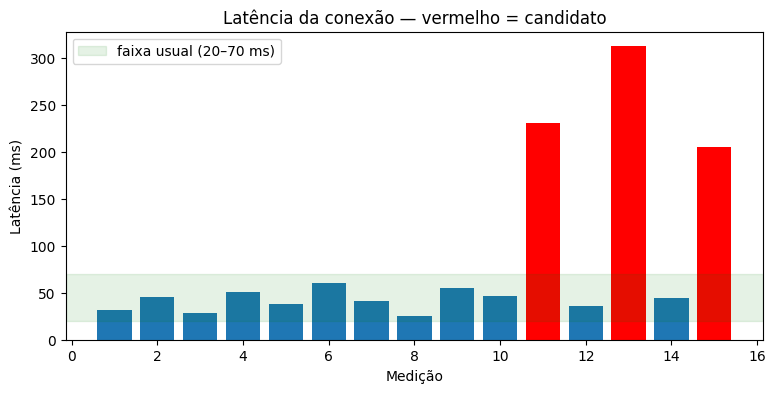

In [ ]:
cores = ["red" if p == -1 else "tab:blue" for p in pred2]
plt.figure(figsize=(9, 4))
plt.bar(range(1, len(latencias) + 1), latencias, color=cores)
plt.axhspan(20, 70, color="green", alpha=0.1, label="faixa usual (20–70 ms)")
plt.xlabel("Medição"); plt.ylabel("Latência (ms)")
plt.title("Latência da conexão — vermelho = candidato")
plt.legend(); plt.show()

---
## Exercício 3 — Consumo de combustível

In [ ]:
consumo = [[10, 1.0], [20, 1.8], [30, 2.6], [40, 3.5], [50, 4.3],
           [60, 5.1], [70, 6.0], [80, 7.0], [90, 8.0], [100, 20.0]]
df3 = pd.DataFrame(consumo, columns=["distancia_km", "litros"])

modelo3 = IsolationForest(contamination=0.1, random_state=SEED)
df3["rotulo"] = modelo3.fit_predict(df3[["distancia_km", "litros"]])
df3["km_por_litro"] = (df3["distancia_km"] / df3["litros"]).round(1)
df3

,distancia_km,litros,rotulo,km_por_litro
0,10,1.0,1,10.0
1,20,1.8,1,11.1
2,30,2.6,1,11.5
3,40,3.5,1,11.4
4,50,4.3,1,11.6
5,60,5.1,1,11.8
6,70,6.0,1,11.7
7,80,7.0,1,11.4
8,90,8.0,1,11.2
9,100,20.0,-1,5.0


In [ ]:
print("Combinação incomum:")
df3[df3["rotulo"] == -1]

Combinação incomum:


,distancia_km,litros,rotulo,km_por_litro
9,100,20.0,-1,5.0


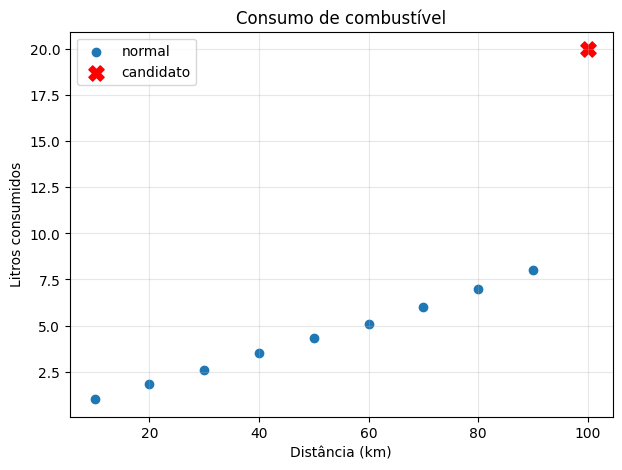

In [ ]:
normais = df3[df3["rotulo"] == 1]
anom = df3[df3["rotulo"] == -1]

plt.figure(figsize=(7, 5))
plt.scatter(normais["distancia_km"], normais["litros"], label="normal")
plt.scatter(anom["distancia_km"], anom["litros"], color="red", s=120, marker="X", label="candidato")
plt.xlabel("Distância (km)"); plt.ylabel("Litros consumidos")
plt.title("Consumo de combustível")
plt.legend(); plt.grid(alpha=0.3); plt.show()

---
## Exercício 4 — Viagens de ônibus urbano

In [ ]:
viagens = [[32, 3], [45, 5], [50, 4], [60, 6], [55, 5],
           [70, 7], [65, 6], [80, 8], [75, 7], [10, 45]]
df4 = pd.DataFrame(viagens, columns=["passageiros", "atraso_min"])

modelo4 = IsolationForest(contamination=0.1, random_state=SEED)
df4["rotulo"] = modelo4.fit_predict(df4[["passageiros", "atraso_min"]])
print("Viagem candidata:")
df4[df4["rotulo"] == -1]

Viagem candidata:


,passageiros,atraso_min,rotulo
9,10,45,-1


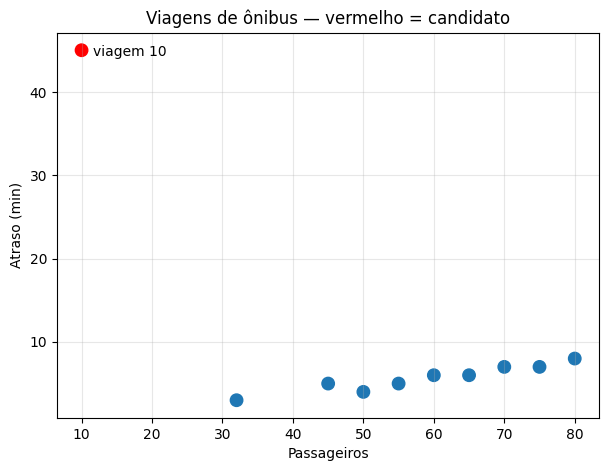

In [ ]:
cores = df4["rotulo"].map({1: "tab:blue", -1: "red"})
plt.figure(figsize=(7, 5))
plt.scatter(df4["passageiros"], df4["atraso_min"], c=cores, s=80)
for i, r in df4[df4["rotulo"] == -1].iterrows():
    plt.annotate(f"viagem {i+1}", (r["passageiros"], r["atraso_min"]),
                 textcoords="offset points", xytext=(8, -4))
plt.xlabel("Passageiros"); plt.ylabel("Atraso (min)")
plt.title("Viagens de ônibus — vermelho = candidato")
plt.grid(alpha=0.3); plt.show()

---
## Exercício 5 — Regra fixa versus Isolation Forest

In [ ]:
consumo_agua = [[48], [52], [50], [55], [49], [53], [51], [54], [56], [12], [180]]
df5 = pd.DataFrame(consumo_agua, columns=["litros"])

LIMITE_MIN, LIMITE_MAX = 30, 100
df5["regra"] = np.where((df5["litros"] < LIMITE_MIN) | (df5["litros"] > LIMITE_MAX), -1, 1)

modelo5 = IsolationForest(contamination=2/11, random_state=SEED)
df5["iforest"] = modelo5.fit_predict(df5[["litros"]])

df5["concordam"] = df5["regra"] == df5["iforest"]
df5

,litros,regra,iforest,concordam
0,48,1,1,True
1,52,1,1,True
2,50,1,1,True
3,55,1,1,True
4,49,1,1,True
5,53,1,1,True
6,51,1,1,True
7,54,1,1,True
8,56,1,1,True
9,12,-1,-1,True


In [ ]:
cand_regra = set(df5.loc[df5["regra"] == -1, "litros"])
cand_if = set(df5.loc[df5["iforest"] == -1, "litros"])
print("Candidatos pela regra fixa:     ", sorted(cand_regra))
print("Candidatos pelo Isolation Forest:", sorted(cand_if))
print("Os candidatos são iguais?", cand_regra == cand_if)

Candidatos pela regra fixa:      [12, 180]
Candidatos pelo Isolation Forest: [12, 180]
Os candidatos são iguais? True


---
## Exercício 6 — Criação de um problema completo

In [ ]:
site = pd.DataFrame({
    "dia": range(1, 19),
    "acessos":       [310, 295, 330, 305, 320, 290, 2400, 315, 300, 325, 298, 312, 308, 1500, 318, 302, 327, 296],
    "tempo_medio_s": [ 95, 102,  88, 110,  97, 105,    3,  99, 101,  93, 108,  96, 100,   92,  98, 104,  90, 107],
})

modelo6 = IsolationForest(contamination=2/18, random_state=SEED)
site["rotulo"] = modelo6.fit_predict(site[["acessos", "tempo_medio_s"]])
site["score"] = modelo6.decision_function(site[["acessos", "tempo_medio_s"]]).round(3)

print("Candidatos:")
site[site["rotulo"] == -1]

Candidatos:


,dia,acessos,tempo_medio_s,rotulo,score
6,7,2400,3,-1,-0.281
13,14,1500,92,-1,-0.127


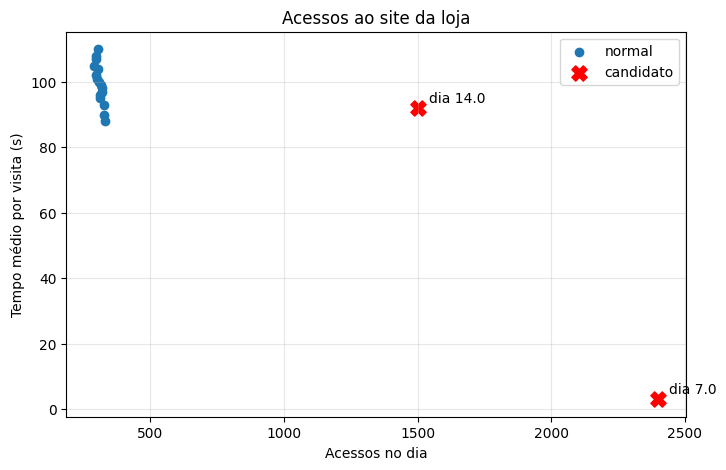

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
n = site[site["rotulo"] == 1]; a = site[site["rotulo"] == -1]
ax.scatter(n["acessos"], n["tempo_medio_s"], label="normal")
ax.scatter(a["acessos"], a["tempo_medio_s"], color="red", s=120, marker="X", label="candidato")
for _, r in a.iterrows():
    ax.annotate(f"dia {r['dia']}", (r["acessos"], r["tempo_medio_s"]),
                textcoords="offset points", xytext=(8, 4))
ax.set_xlabel("Acessos no dia"); ax.set_ylabel("Tempo médio por visita (s)")
ax.set_title("Acessos ao site da loja")
ax.legend(); ax.grid(alpha=0.3); plt.show()

---
## Exercício 7 — Sensores ambientais em arquivo CSV

In [ ]:
dados = pd.read_csv("sensores_ambientais.csv")
print(dados.head())

  id_leitura        data  temperatura  umidade
0       L001  2026-08-01           21       52
1       L002  2026-08-02           22       55
2       L003  2026-08-03           20       48
3       L004  2026-08-04           23       57
4       L005  2026-08-05           21       51


In [ ]:
caracteristicas = ["temperatura", "umidade"]
X7 = dados[caracteristicas]

modelo7 = IsolationForest(contamination=0.15, random_state=SEED)
dados["rotulo"] = modelo7.fit_predict(X7)
dados["score"] = modelo7.decision_function(X7).round(3)

print("Leituras candidatas:", dados.loc[dados["rotulo"] == -1, "id_leitura"].tolist())
dados[dados["rotulo"] == -1]

Leituras candidatas: ['L011', 'L017', 'L020']


,id_leitura,data,temperatura,umidade,rotulo,score
10,L011,2026-08-11,38,18,-1,-0.188
16,L017,2026-08-17,8,92,-1,-0.264
19,L020,2026-08-20,35,25,-1,-0.165


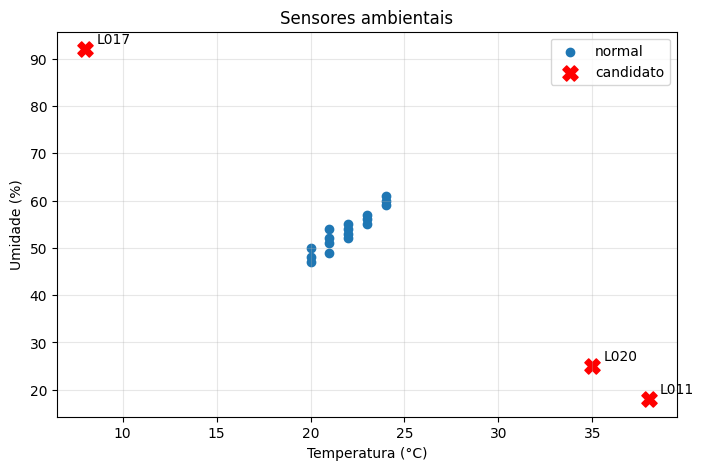

In [ ]:
n = dados[dados["rotulo"] == 1]; a = dados[dados["rotulo"] == -1]
plt.figure(figsize=(8, 5))
plt.scatter(n["temperatura"], n["umidade"], label="normal")
plt.scatter(a["temperatura"], a["umidade"], color="red", s=120, marker="X", label="candidato")
for _, r in a.iterrows():
    plt.annotate(r["id_leitura"], (r["temperatura"], r["umidade"]),
                 textcoords="offset points", xytext=(8, 4))
plt.xlabel("Temperatura (°C)"); plt.ylabel("Umidade (%)")
plt.title("Sensores ambientais")
plt.legend(); plt.grid(alpha=0.3); plt.show()

In [ ]:

print(dados.loc[dados["rotulo"] == 1, caracteristicas].describe().loc[["min", "mean", "max"]].round(1))

      temperatura  umidade
min          20.0     47.0
mean         21.9     53.7
max          24.0     61.0


---
## Exercício 8 — Vendas de comércio eletrônico em arquivo CSV

In [ ]:
dados = pd.read_csv("vendas_ecommerce.csv")
print(dados.head())

  id_venda        data  valor_total  quantidade_itens  desconto_percentual
0     V001  2026-08-01        120.0                 3                    5
1     V002  2026-08-02         85.5                 2                    0
2     V003  2026-08-03        240.0                 5                   10
3     V004  2026-08-04        310.0                 6                   15
4     V005  2026-08-05         95.0                 2                    5


In [ ]:

caracteristicas = ["valor_total", "quantidade_itens", "desconto_percentual"]
X8 = dados[caracteristicas]

modelo8 = IsolationForest(contamination=0.15, random_state=SEED)
dados["rotulo"] = modelo8.fit_predict(X8)
dados["score"] = modelo8.decision_function(X8).round(3)
dados["valor_por_item"] = (dados["valor_total"] / dados["quantidade_itens"]).round(2)

print("Vendas candidatas:")
dados[dados["rotulo"] == -1]

Vendas candidatas:


,id_venda,data,valor_total,quantidade_itens,desconto_percentual,rotulo,score,valor_por_item
10,V011,2026-08-11,5800.0,1,90,-1,-0.120,5800.0
16,V017,2026-08-17,35.0,25,0,-1,-0.074,1.4
19,V020,2026-08-20,4200.0,2,85,-1,-0.084,2100.0


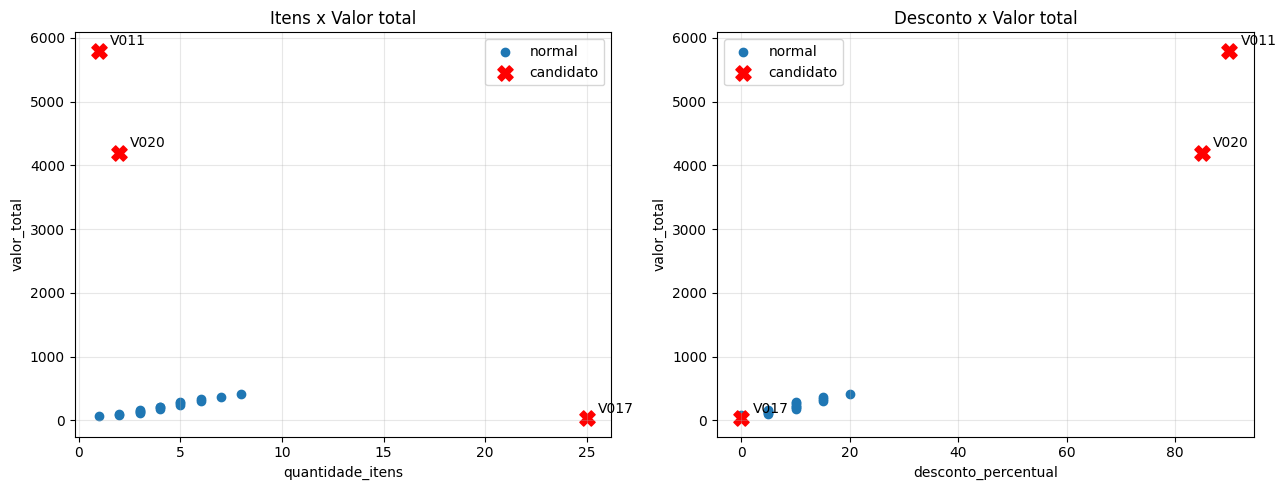

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
n = dados[dados["rotulo"] == 1]; a = dados[dados["rotulo"] == -1]

pares = [("quantidade_itens", "valor_total", "Itens x Valor total"),
         ("desconto_percentual", "valor_total", "Desconto x Valor total")]
for ax, (x, y, titulo) in zip(axes, pares):
    ax.scatter(n[x], n[y], label="normal")
    ax.scatter(a[x], a[y], color="red", s=120, marker="X", label="candidato")
    for _, r in a.iterrows():
        ax.annotate(r["id_venda"], (r[x], r[y]), textcoords="offset points", xytext=(8, 4))
    ax.set_xlabel(x); ax.set_ylabel(y); ax.set_title(titulo)
    ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

In [ ]:
print("Faixa das vendas normais:")
print(dados.loc[dados["rotulo"] == 1, caracteristicas + ["valor_por_item"]].describe().loc[["min", "mean", "max"]].round(1))

Faixa das vendas normais:
      valor_total  quantidade_itens  desconto_percentual  valor_por_item
min          72.0               1.0                  0.0            40.0
mean        214.3               4.2                  8.8            51.3
max         420.0               8.0                 20.0            72.0
